# Transformer Summarizer — Abstractive Russian News Summarization

Train a Transformer encoder-decoder to generate abstractive summaries of
Russian news articles, on the
[IlyaGusev/gazeta](https://huggingface.co/datasets/IlyaGusev/gazeta) corpus.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import re
from pathlib import Path

import pandas as pd
import sentencepiece as spm
import torch
from colorama import Fore, Style
from datasets import load_dataset
from dotenv import load_dotenv
from torch.utils.data import DataLoader
from torchmetrics.text import BLEUScore

from dl_roadmap.chapters.summarization import (
    SummarizationDataset,
    Summarizer,
    prepare_gazeta,
)
from dl_roadmap.chapters.summarization.dataset import make_collate_fn
from dl_roadmap.engine import (
    CombinedEarlyStopping,
    EpochSchedule,
    GapThresholdEarlyStopping,
    MetricEarlyStopping,
    OptimizationConfig,
    OptimizationEngine,
    RougeScore,
    TeacherForcingTrainer,
    Warmup,
)
from dl_roadmap.losses import make_token_loss
from dl_roadmap.utils import (
    LoggerConfig,
    load_model,
    notify_model_trained,
    save_model,
    seed_everything,
    setup_logger,
)
from dl_roadmap.visualization import plot_training_history

In [3]:
%matplotlib inline

pd.set_option("display.width", 150)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", None)

load_dotenv()
seed_everything()
setup_logger(LoggerConfig(log_level="WARNING"))

In [4]:
PROJECT_NAME = "10_summarizer"

DATA_DIR = Path("../data")
MODEL_DIR = Path("../models") / PROJECT_NAME
REPORT_DIR = Path("../reports")

RAW_DATA_DIR = DATA_DIR / "raw" / PROJECT_NAME
PROCESSED_DATA_DIR = DATA_DIR / "processed" / PROJECT_NAME
TOKENIZER_DIR = MODEL_DIR / "tokenizer"
OPTUNA_DIR = MODEL_DIR / "optuna"
FIG_DIR = REPORT_DIR / "figures" / PROJECT_NAME


DIRECTORIES = (
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    MODEL_DIR,
    TOKENIZER_DIR,
    OPTUNA_DIR,
    FIG_DIR,
)

for directory in DIRECTORIES:
    directory.mkdir(parents=True, exist_ok=True)

## Dataset

In [5]:
dataset = load_dataset("IlyaGusev/gazeta", cache_dir=RAW_DATA_DIR)

train_df = dataset["train"].shuffle(seed=42).to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

### Overview

In [6]:
print(f"{Fore.MAGENTA}DataFrame Info:{Style.RESET_ALL}")
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"\n{Fore.CYAN}====== {name} ======{Style.RESET_ALL}")
    df.info()

DataFrame Info:

====== train ======
<class 'pandas.DataFrame'>
RangeIndex: 60964 entries, 0 to 60963
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   text     60964 non-null  str  
 1   summary  60964 non-null  str  
 2   title    60964 non-null  str  
 3   date     60964 non-null  str  
 4   url      60964 non-null  str  
dtypes: str(5)
memory usage: 522.9 MB

====== val ======
<class 'pandas.DataFrame'>
RangeIndex: 6369 entries, 0 to 6368
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   text     6369 non-null   str  
 1   summary  6369 non-null   str  
 2   title    6369 non-null   str  
 3   date     6369 non-null   str  
 4   url      6369 non-null   str  
dtypes: str(5)
memory usage: 53.3 MB

====== test ======
<class 'pandas.DataFrame'>
RangeIndex: 6793 entries, 0 to 6792
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------

In [7]:
print(f"{Fore.YELLOW}First Rows of DataFrame:{Style.RESET_ALL}")
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"\n{Fore.CYAN}====== {name} ======{Style.RESET_ALL}")
    print(df.head())

First Rows of DataFrame:

====== train ======
                                                text                                            summary                                   title  \
0  В сети появилось видео задержания 58-летнего в...  Департамент транспорта Москвы проведет внеплан...  «Мы проведем тщательное расследование»   
1  В преддверии первого матча раунда плей-офф Лиг...  Накануне матча с «Рубином» главный тренер «Лио...          «Рубин» не боимся, но уважаем»   
2  Mail.ru Group , владеющая 39,99% «ВКонтакте», ...  Павел Дуров получит операционный контроль над ...               «ВКонтакте» под контролем   
3  Американский сенатор Джон Маккейн отреагировал...  Сенатор-республиканец Джон Маккейн молится за ...      Танкер протаранил «Джона Маккейна»   
4  Во вторник норвежский Нобелевский комитет расп...  Вручение Нобелевской премии мира спровоцировал...                Нобелевская премия войны   

                  date                                                u

In [8]:
print(f"{Fore.RED}Missing Values in Each Column:{Style.RESET_ALL}")
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"\n{Fore.CYAN}====== {name} ======{Style.RESET_ALL}")
    missing = df.isnull().sum()
    missing_percent = (missing / len(df)) * 100
    missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_percent})
    print(missing_df)

Missing Values in Each Column:

====== train ======
         Missing Count  Missing %
text                 0        0.0
summary              0        0.0
title                0        0.0
date                 0        0.0
url                  0        0.0

====== val ======
         Missing Count  Missing %
text                 0        0.0
summary              0        0.0
title                0        0.0
date                 0        0.0
url                  0        0.0

====== test ======
         Missing Count  Missing %
text                 0        0.0
summary              0        0.0
title                0        0.0
date                 0        0.0
url                  0        0.0


### Preprocessing

In [9]:
train_df = prepare_gazeta(train_df, cache_file=PROCESSED_DATA_DIR / "train_df.csv")
val_df = prepare_gazeta(val_df, cache_file=PROCESSED_DATA_DIR / "val_df.csv")
test_df = prepare_gazeta(test_df, cache_file=PROCESSED_DATA_DIR / "test_df.csv")

In [10]:
print(f"{Fore.MAGENTA}DataFrame Info:{Style.RESET_ALL}")
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"\n{Fore.CYAN}====== {name} ======{Style.RESET_ALL}")
    df.info()

DataFrame Info:

====== train ======
<class 'pandas.DataFrame'>
RangeIndex: 60421 entries, 0 to 60420
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   text     60421 non-null  str  
 1   summary  60421 non-null  str  
dtypes: str(2)
memory usage: 506.1 MB

====== val ======
<class 'pandas.DataFrame'>
RangeIndex: 6321 entries, 0 to 6320
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   text     6321 non-null   str  
 1   summary  6321 non-null   str  
dtypes: str(2)
memory usage: 51.3 MB

====== test ======
<class 'pandas.DataFrame'>
RangeIndex: 6741 entries, 0 to 6740
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   text     6741 non-null   str  
 1   summary  6741 non-null   str  
dtypes: str(2)
memory usage: 55.9 MB


In [11]:
print(f"{Fore.YELLOW}First Rows of DataFrame:{Style.RESET_ALL}")
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"\n{Fore.CYAN}====== {name} ======{Style.RESET_ALL}")
    print(df.head())

First Rows of DataFrame:

====== train ======
                                                text                                            summary
0  В сети появилось видео задержания 58-летнего в...  Департамент транспорта Москвы проведет внеплан...
1  В преддверии первого матча раунда плей-офф Лиг...  Накануне матча с «Рубином» главный тренер «Лио...
2  Mail.ru Group , владеющая 39,99% «ВКонтакте», ...  Павел Дуров получит операционный контроль над ...
3  Американский сенатор Джон Маккейн отреагировал...  Сенатор-республиканец Джон Маккейн молится за ...
4  Во вторник норвежский Нобелевский комитет расп...  Вручение Нобелевской премии мира спровоцировал...

====== val ======
                                                text                                            summary
0  В 2020 году инфляция в России составит 3,5-4%,...  В уходящем году инфляция в России находится на...
1  Глава Белого дома Дональд Трамп выразил надежд...  Мировая общественность призвала лидера КНДР Ки...

### SentencePiece

In [12]:
force_tokenizer_train = False

if force_tokenizer_train or not (TOKENIZER_DIR / "sp.model").is_file():
    data_path = PROCESSED_DATA_DIR / "data.txt"
    data_path.write_text("\n".join(train_df["text"]), encoding="utf-8")

    spm.SentencePieceTrainer.train(
        input=str(data_path),
        model_prefix=str(TOKENIZER_DIR / "sp"),
        vocab_size=16000,
        model_type="unigram",
        character_coverage=1.0,
        byte_fallback=True,
        max_sentence_length=16384,
        num_threads=os.cpu_count() or 4,
        pad_id=3,
        unk_id=2,
        bos_id=0,
        eos_id=1,
        pad_piece="<PAD>",
        unk_piece="<UNK>",
        bos_piece="<BOS>",
        eos_piece="<EOS>",
    )

sp = spm.SentencePieceProcessor(model_file=str(TOKENIZER_DIR / "sp.model"))

### Collation

In [13]:
pad_id = sp.pad_id()
collate_fn = make_collate_fn(pad_id)

## Tools

In [14]:
loss = make_token_loss(pad_id, label_smoothing=0.1)

## Training

In [15]:
model_dim = 256
num_encoder_layers = 6
num_decoder_layers = 3
ffn_ratio = 2
num_heads = 4

lr = 3.17e-4
dropout = 0.163
weight_decay = 3.2e-4

batch_size = 32
warmup_epochs = 1.0

In [16]:
seed = 42

torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [17]:
train_dataset = SummarizationDataset(train_df, sp)
val_dataset = SummarizationDataset(val_df, sp)
test_dataset = SummarizationDataset(test_df, sp)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn,
    drop_last=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn,
    drop_last=True,
)

In [ ]:
model = Summarizer(
    sp,
    model_dim=model_dim,
    num_heads=num_heads,
    num_encoder_layers=num_encoder_layers,
    num_decoder_layers=num_decoder_layers,
    ffn_dim=(ffn_ratio * model_dim),
    dropout=dropout,
)

decay, no_decay = [], []
for n, p in model.named_parameters():
    if n.endswith("bias") or "norm" in n:
        no_decay.append(p)
    else:
        decay.append(p)

opt = torch.optim.AdamW(
    [
        {"params": decay, "weight_decay": weight_decay},
        {"params": no_decay, "weight_decay": 0.0},
    ],
    lr=lr,
)

plateau = torch.optim.lr_scheduler.ReduceLROnPlateau(
    opt,
    mode="min",
    factor=0.3,
    patience=3,
    min_lr=3e-5,
    threshold=0.01,
    threshold_mode="abs",
    cooldown=1,
)

scheduler = Warmup(opt, warmup_epochs, every="interval", then=plateau)

rouge_early = MetricEarlyStopping("val_rouge_mean", patience=5, min_delta=1e-3)
early_stopping = CombinedEarlyStopping(
    [rouge_early, GapThresholdEarlyStopping(patience=5, threshold=0.8)],
    combine="any",
    restore_best_weights=True,
)

rouge = RougeScore(
    decode=sp.decode,
    pad_id=pad_id,
    on_train=False,
    max_batches=20,
)

optimization_config = OptimizationConfig(
    grad_clip_norm=1.0,
    grad_normalizer=loss.grad_normalizer,
    amp="auto",
)
trainer = TeacherForcingTrainer(
    model=model,
    loss_fn=loss.loss_fn,
    optimization=OptimizationEngine(opt, scheduler, optimization_config),
    loss_tracker=loss.loss_tracker,
    metrics={"rouge": rouge},
)

In [19]:
train_model = False
model_path = MODEL_DIR / "summarizer.model"
trainer_path = MODEL_DIR / "summarizer.trainer"


def train() -> None:
    """Fits the model, saves the checkpoint, and reports the final losses."""
    trainer.fit(
        train_loader,
        val_loader,
        schedule=EpochSchedule(100),
        early_stopping=early_stopping,
    )
    trainer.state_store.save(trainer_path)
    save_model(model, model_path)
    notify_model_trained(
        "Summarizer",
        {
            "best_epoch": rouge_early.best_interval,
            "train_loss": trainer.state_store.history["train_loss"][-1],
            "val_loss": trainer.state_store.history["val_loss"][-1],
        },
    )


if train_model or not model_path.is_file():
    train()
else:
    load_model(model, model_path)
    trainer.state_store.load(trainer_path)

epoch  44/100:  44%[========>           ] 82940/188500 :: eta=3:31:40, status=early stopped, train_loss=3.684, val_loss=3.982


## Results

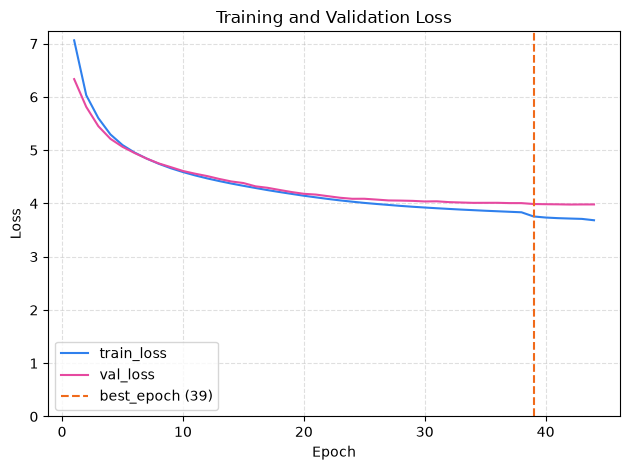

In [20]:
history = trainer.state_store.history
plot_training_history(
    history["train_loss"],
    history["val_loss"],
    best_epoch=rouge_early.best_interval,
    filename=FIG_DIR / "training_history.png",
)

---

In [26]:
@torch.no_grad()
def generate_summary(
    text: str,
    model: Summarizer,
    sp: spm.SentencePieceProcessor,
    max_length: int = 100,
    min_length: int = 35,
    beam_width: int = 5,
    length_penalty_alpha: float = 1.0,
    repetition_penalty: float = 1.2,
    no_repeat_ngram_size: int = 3,
) -> str:
    """Decodes a summary for an article using beam search.

    Args:
        text: Raw article text to summarize.
        model: A trained ``Summarizer`` model.
        sp: SentencePiece model used to encode ``text`` and decode the
            generated ids.
        max_length: Maximum number of tokens to generate.
        min_length: Number of tokens generated before ``<EOS>`` is allowed.
        beam_width: Number of hypotheses kept alive at each step.
        length_penalty_alpha: Strength of the length penalty applied when
            ranking completed hypotheses.
        repetition_penalty: Discount applied to already generated tokens.
        no_repeat_ngram_size: Length of the n-grams that may not repeat.

    Returns:
        The generated summary text, decoded up to (and excluding) ``<EOS>``.
    """
    device = next(model.parameters()).device

    src_ids = [sp.bos_id(), *sp.encode(text, out_type=int), sp.eos_id()]
    if len(src_ids) > SummarizationDataset.MAX_TEXT_LEN:
        src_ids = [*src_ids[: SummarizationDataset.MAX_TEXT_LEN - 1], sp.eos_id()]

    x = torch.tensor([src_ids], dtype=torch.long, device=device)

    ids = model.generate(
        x,
        max_length=min(max_length, SummarizationDataset.MAX_SUMMARY_LEN),
        min_length=min_length,
        beam_width=beam_width,
        length_penalty_alpha=length_penalty_alpha,
        repetition_penalty=repetition_penalty,
        no_repeat_ngram_size=no_repeat_ngram_size,
    )[0].tolist()
    return sp.decode(ids)

---

In [30]:
for _, row in val_df.head(20).iterrows():
    summary = generate_summary(row["text"], model, sp)

    print(f"{Fore.CYAN}Text:{Style.RESET_ALL} {row['text']}")
    print(f"{Fore.GREEN}Reference:{Style.RESET_ALL} {row['summary']}")
    print(f"{Fore.YELLOW}Generated:{Style.RESET_ALL} {summary}\n")

Text: В 2020 году инфляция в России составит 3,5-4%, прогнозирует Центробанк. В первом квартале она ожидается так и вовсе ниже 3%. Впрочем, на ряд продовольственных товаров цены будут расти гораздо более высокими темпами. «Газета.Ru» разбиралась, какие продукты подорожают в новом году гораздо сильнее других. В 2019 году стоимость молока-сырья выросла на 9% и, как следствие, увеличилась цена на готовую продукцию: питьевое молоко за год подорожало на 7%, кефир, ряженка, творог — на 6 %, йогурт – на 8%, сметана на 7%, мороженое на 9%, полутвердые сыры на 10%, сливочное масло – на 11%, рассказала «Газете.Ru» заместитель председателя комитета МТПП по развитию предпринимательства в АПК, генеральный директор «Petrova 5 Consulting» Марина Петрова. По ее словам, в 2020 году стоит ожидать дальнейшего увеличения цен на молочные продукты. Темпы повышения, по ее словам, будут сопоставимы с ростом в 2019 году. «Производители плавно поднимают цены, потому что беспокоятся о возможном снижении объемов 

In [28]:
def norm(s: str) -> str:
    """Lowercases the text and splits it into word and punctuation tokens."""
    return " ".join(re.findall(r"\w+|[^\w\s]", s.lower()))


bleu = BLEUScore(n_gram=4, smooth=True)

for _, row in val_df.head(100).iterrows():
    hyp = generate_summary(row["text"], model, sp)
    bleu.update([norm(hyp)], [[norm(row["summary"])]])

print(f"{Fore.MAGENTA}BLEU score:{Style.RESET_ALL} {bleu.compute().item()}")

BLEU score: 0.1081930622458458


In [29]:
from colorama import Fore, Style
from torchmetrics.text import BLEUScore, ROUGEScore


def norm(s: str) -> str:
    """Lowercases the text and splits it into word and punctuation tokens."""
    return " ".join(re.findall(r"\w+|[^\w\s]", s.lower()))


rouge = ROUGEScore(
    rouge_keys=("rouge1", "rouge2", "rougeL"),
    accumulate="avg",
)

for _, row in val_df.head(100).iterrows():
    hypothesis = norm(generate_summary(row["text"], model, sp))
    reference = norm(row["summary"])

    rouge.update(
        hypothesis,
        reference,
    )

rouge_scores = rouge.compute()

rouge1 = rouge_scores["rouge1_fmeasure"].item()
rouge2 = rouge_scores["rouge2_fmeasure"].item()
rougeL = rouge_scores["rougeL_fmeasure"].item()
rouge_mean = (rouge1 + rouge2 + rougeL) / 3

print(f"{Fore.MAGENTA}ROUGE-1 F1:{Style.RESET_ALL} {rouge1:.6f}")
print(f"{Fore.MAGENTA}ROUGE-2 F1:{Style.RESET_ALL} {rouge2:.6f}")
print(f"{Fore.MAGENTA}ROUGE-L F1:{Style.RESET_ALL} {rougeL:.6f}")
print(f"{Fore.MAGENTA}ROUGE mean:{Style.RESET_ALL} {rouge_mean:.6f}")

ROUGE-1 F1: 0.124906
ROUGE-2 F1: 0.049000
ROUGE-L F1: 0.121573
ROUGE mean: 0.098493
